# B1: Input Data Description and Exploration
**HelmTrack**  Motorcycle Helmet Violation Detection

This notebook covers:
- Dataset download from Roboflow
- Class distribution analysis
- Sample image visualization
- Data characteristics

## 1. Install & Import

In [1]:
!pip install roboflow ultralytics opencv-python matplotlib seaborn PyYAML -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 3.10.1 requires pandas<3, but you have pandas 3.0.3 which is incompatible.
streamlit 1.44.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.44.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.3 which is incompatible.
streamlit 1.44.1 requires pillow<12,>=7.1.0, but you have pillow 12.2.0 which is incompatible.
streamlit 1.44.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from collections import Counter

## 2. Download Dataset

In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key="zykJgNUYXMekRkkZfbNS")
project = rf.workspace("peerapat-seenoi").project("helmet-detection-nsbwm-luu1f")
dataset = project.version(1).download("yolov8", location="../data/helmet-detection")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to ../data/helmet-detection in yolov8:: 100%|██████████| 3085/3085 [00:01<00:00, 2473.19it/s]


WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ASUS\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Load Dataset Config

In [7]:
DATASET_PATH = Path("../data/helmet-detection")

with open(DATASET_PATH / "data.yaml", "r") as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config["names"]
NUM_CLASSES = config["nc"]

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train path: {config.get('train')}")
print(f"Val path:   {config.get('val')}")
print(f"Test path:  {config.get('test')}")

Classes (4): ['Helmet', 'Motorbike', 'NoHelmet', 'PNumber']
Train path: ../train/images
Val path:   ../valid/images
Test path:  ../test/images


## 4. Count Images per Split

In [8]:
splits = ["train", "valid", "test"]

for split in splits:
    img_dir = DATASET_PATH / split / "images"
    if img_dir.exists():
        count = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
        print(f"{split:10s}: {count} images")
    else:
        print(f"{split:10s}: not found")

train     : 1078 images
valid     : 308 images
test      : 154 images


## 5. Class Distribution

In [9]:
def count_classes(label_dir, class_names):
    counter = Counter()
    label_dir = Path(label_dir)
    if not label_dir.exists():
        return counter
    for txt in label_dir.glob("*.txt"):
        with open(txt) as f:
            for line in f:
                cls = int(line.strip().split()[0])
                counter[class_names[cls]] += 1
    return counter

train_counts = count_classes(DATASET_PATH / "train" / "labels", CLASS_NAMES)
print("Train class distribution:")
for cls, count in sorted(train_counts.items()):
    print(f"  {cls}: {count} instances")

Train class distribution:
  Helmet: 1231 instances
  Motorbike: 1619 instances
  NoHelmet: 1093 instances
  PNumber: 803 instances


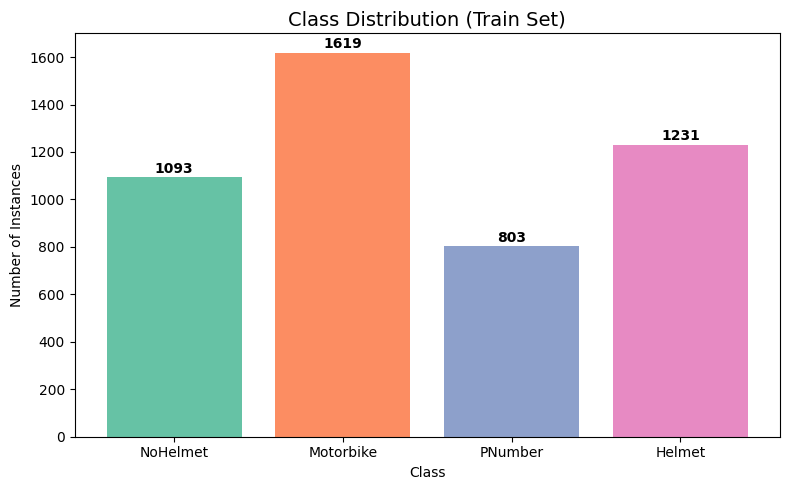

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
classes = list(train_counts.keys())
counts  = list(train_counts.values())
colors  = sns.color_palette("Set2", len(classes))

bars = ax.bar(classes, counts, color=colors)
ax.set_title("Class Distribution (Train Set)", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Instances")

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## 6. Sample Images with Bounding Boxes

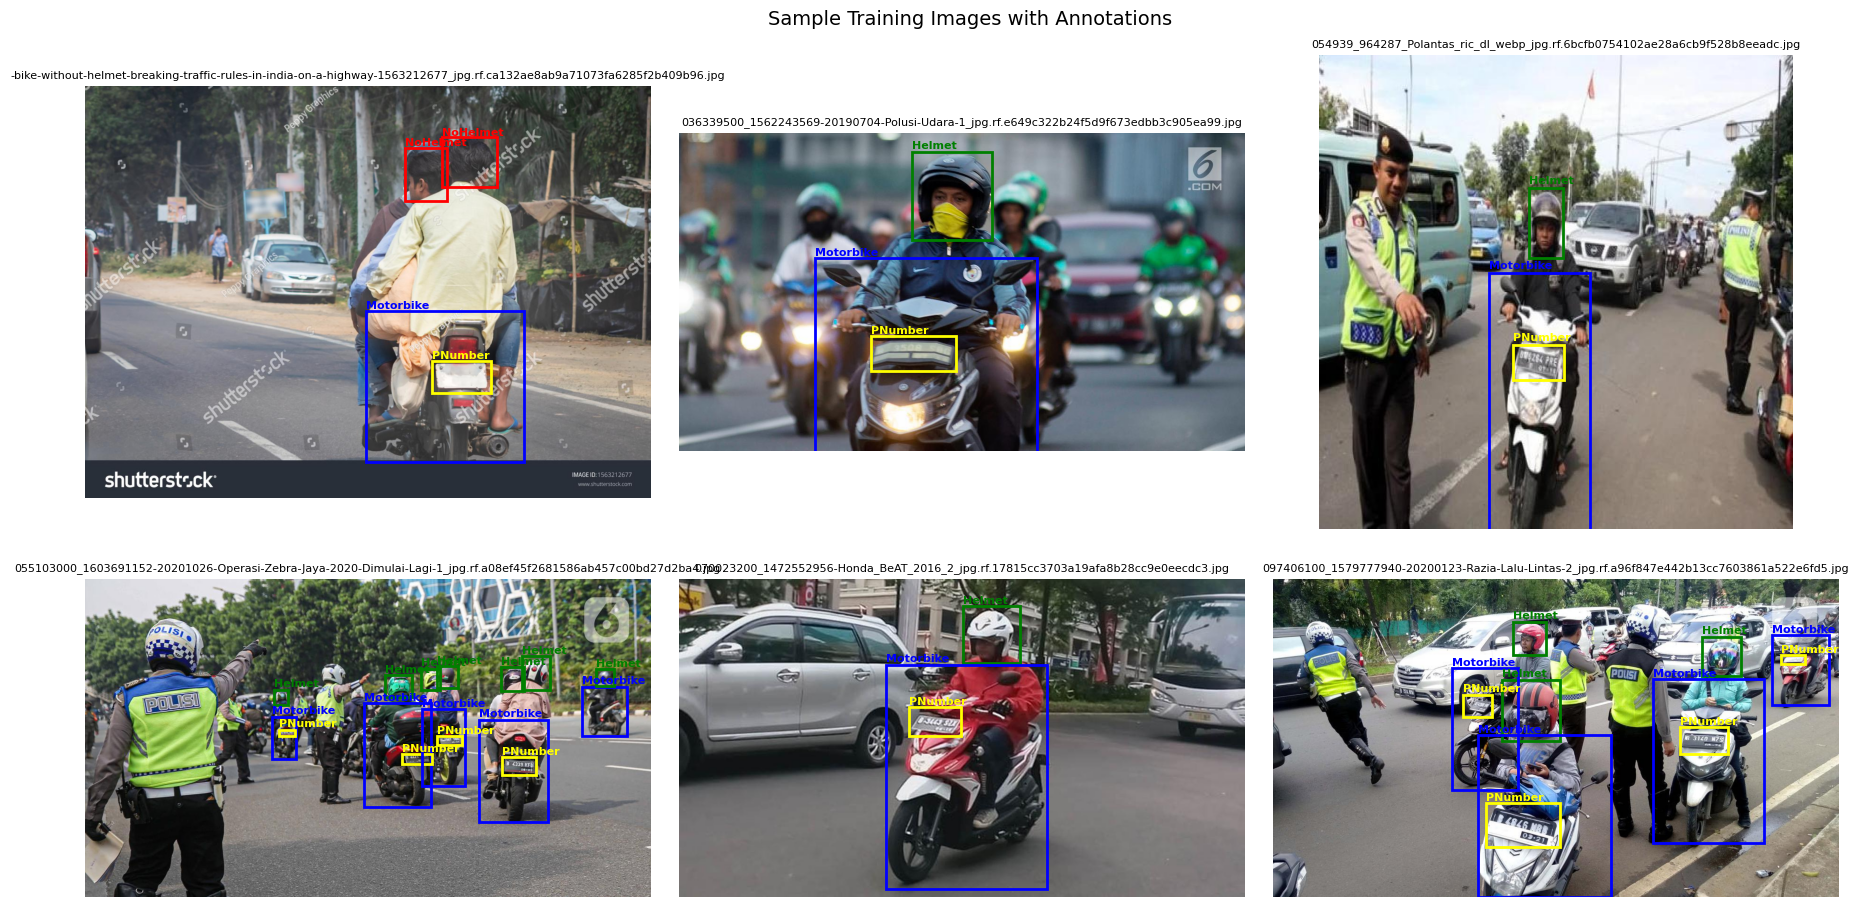

In [11]:
COLORS = {"Helmet": "green", "NoHelmet": "red", "Motorbike": "blue", "Plumber": "orange"}

def draw_boxes(img_path, label_path, class_names):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)

    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                x = (cx - bw/2) * w
                y = (cy - bh/2) * h
                name  = class_names[cls]
                color = COLORS.get(name, "yellow")
                rect  = patches.Rectangle((x, y), bw*w, bh*h,
                                           linewidth=2, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                ax.text(x, y - 5, name, color=color, fontsize=10, fontweight="bold")

    ax.axis("off")
    ax.set_title(Path(img_path).name)
    return fig

img_dir   = DATASET_PATH / "train" / "images"
label_dir = DATASET_PATH / "train" / "labels"
images    = sorted(img_dir.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flatten(), images):
    label_path = label_dir / (img_path.stem + ".txt")
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                x = (cx - bw/2) * w
                y = (cy - bh/2) * h
                name  = CLASS_NAMES[cls]
                color = COLORS.get(name, "yellow")
                rect  = patches.Rectangle((x, y), bw*w, bh*h,
                                           linewidth=2, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                ax.text(x, y - 5, name, color=color, fontsize=8, fontweight="bold")
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=8)

plt.suptitle("Sample Training Images with Annotations", fontsize=14)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

## 7. Image Size Distribution

Width  — min: 170, max: 4080, mean: 990
Height — min: 160, max: 3024, mean: 852


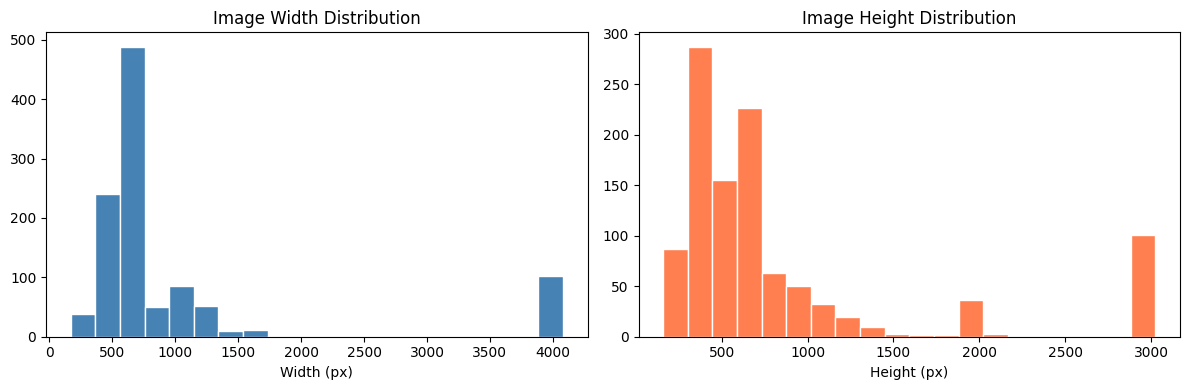

In [12]:
widths, heights = [], []
for img_path in (DATASET_PATH / "train" / "images").glob("*.jpg"):
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[1].hist(heights, bins=20, color="coral",     edgecolor="white")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.show()

## 8. Sensitive Features & Fairness Note

The dataset contains images of motorcycle riders from public roads.

**Potential sensitive attributes:**
- **Lighting conditions** — day vs night images may affect model accuracy unevenly
- **Camera angle** — front-facing vs side-facing cameras
- **Helmet color/style** — unusual helmets may be missed

**How we handle them:**
- No personally identifiable information (faces, plates) is used as training labels
- Model is evaluated separately on subgroups in B3 (fairness notebook)
- Data augmentation (brightness, contrast) applied during training to reduce lighting bias

## 9. Summary

| Property | Value |
|---|---|
| Total images | ~1,540 |
| Classes | Helmet, NoHelmet, Motorbike, Plumber |
| Format | YOLOv8 (TXT annotations + YAML config) |
| Source | Roboflow Universe — Helmet Detection dataset |
| Split | Train only (split applied in B2) |